# Clustering


Dans ce notebook, nous explorons l'utilisation de méthodes d'apprentissage non supervisé pour regrouper les communes selon leurs niveaux de vulnérabilité face au changement climatique et leurs capacités financières.

Les **features (variables)** utilisées pour ce clustering sont :

- **Économie et Revenus** :
  - `ft_rev_ecart_nat` : Écart au revenu médian national.
  - `ft_chomage_tx` : Taux de chômage.
- **Risques Naturels (Scores pondérés)** :
  - `ft_rga_score` : Score d'exposition au Retrait-Gonflement des Argiles (RGA).
  - `ft_tri_score` : Score d'exposition aux inondations (TRI).
- **Historique CatNat** :
  - `ft_catnat_ratio` : Ratio de sinistres CatNat.
  - `ft_catnat_rec_ratio` : Ratio de reconnaissance des arrêtés CatNat.
- **Finances de la Commune** :
  - `ft_dette_recette_ratio` : Ratio dette sur recettes réelles de fonctionnement.
- **Assurances** :
  - `ft_primes_par_habitant` : Montant des primes d'assurance par habitant.
  - `ft_primes_median` : Montant médian des primes d'assurance.
  - `ft_primes_depenses_ratio` : Poids des primes dans les dépenses de fonctionnement.


Notes pour Jacques:

- Virer ICB si on cluster que sur les RGA
- Regarder évolution des primes (en plus du ratio)
- Ajouter les penalités sur les franchise comme pondération des catnats (1 catnat avec franchise doublée = 2 catnats etc, 1 catnat non reconnue = 5 catnats)
- Revenu disponible vs revenu median


## Load tools & parameters


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import duckdb

In [3]:
# ODIS_DUCKDB_FILE = "odis.duckdb"
def run_duckdb_query(q):
    PCC_DUCKDB_FILE = "dev.duckdb"

    con = duckdb.connect(database=PCC_DUCKDB_FILE, read_only=True)
    con.sql(f"ATTACH '{PCC_DUCKDB_FILE}' AS pcc;")
    res = con.sql(q)
    df = res.df()
    con.close()
    return df

In [4]:
QUANT_ECRET = 0.01 #0.01 = 1-99 centiles
CATNAT_CODES = ['SEC',  'ICB', 'IRN']
LOOKBACK_YEAR = 2006
POP_MIN = 100
CATNAT_MIN = 1
PRIMES_MIN = 1000
PRIMES_MAX = 1000000

In [4]:
q = """
    SHOW TABLES
    """

tables = run_duckdb_query(q)
tables.head(20)

,name
0,azi_gaspar
1,bronze_rei
2,budget_communes
3,budget_per_compte_communes
4,catnat_gaspar
5,ccr_details
6,ccr_main_page
7,collectivities_pdf
8,datactivist_commune
9,dicrim_gaspar


## Gather Possible Features


### Fetch Communes Geometries


In [5]:
# Fetch communes with geometries
com = gpd.read_file('../csv_large/a-com2022-topo-2154.json', layer='a_com2022')
com.set_geometry('geometry', crs='EPSG:2154', inplace=True)
com = com.drop(columns=['xcl2154', 'ycl2154', 'id'])
com.head()

,codgeo,dep,reg,libgeo,geometry
0,01001,01,84,L'Abergement-Clémenciat,"POLYGON ((846981.436 6564107.36, 847017.457 65..."
1,01002,01,84,L'Abergement-de-Varey,"POLYGON ((886027.651 6548170.9, 886157.325 654..."
2,01004,01,84,Ambérieu-en-Bugey,"POLYGON ((884889.404 6539629.931, 884795.75 65..."
3,01005,01,84,Ambérieux-en-Dombes,"POLYGON ((845951.25 6547999.078, 846073.72 654..."
4,01006,01,84,Ambléon,"POLYGON ((901336.361 6521123.305, 902460.201 6..."


### Fetch Communes RGA + TRI


In [11]:
# Fetch Communes with houses RGA + TRI risks
risques_nat = pd.read_parquet('../csv/risques_communes_flat.parquet')
risques_nat.head()

,code_commune_insee,total_maisons,rga_1945_1975_faible,rga_1945_1975_moyen,rga_1945_1975_nul,rga_1945_1975_fort,rga_1976_2020_faible,rga_1976_2020_moyen,rga_1976_2020_nul,rga_1976_2020_fort,...,tri_nul_nul,tri_t01_faible,tri_t01_fort,tri_t01_moyen,tri_t02_faible,tri_t02_fort,tri_t02_moyen,tri_t03_faible,tri_t03_fort,tri_t03_moyen
0,01001,358,21,0,0,0,184,2,0,0,...,358,0,0,0,0,0,0,0,0,0
1,01002,168,1,12,0,0,2,25,3,0,...,168,0,0,0,0,0,0,0,0,0
2,01004,3254,337,165,1,0,930,869,11,0,...,3254,0,0,0,0,0,0,0,0,0
3,01005,616,82,0,0,0,328,0,2,0,...,616,0,0,0,0,0,0,0,0,0
4,01006,62,5,0,0,0,13,0,0,0,...,62,0,0,0,0,0,0,0,0,0


In [12]:
#Add RGA and TRI Score + Cleanup
# RGA Score
period_weights = {
    '1945_1975': 0.5,
    '1976_2020': 1.0,
    'post2020': 0.5,
    'pre1945': 0.0
}

severity_weights = {
    'faible': 1.0,
    'moyen': 5.0,
    'fort': 10.0
}

# Calculate refined weighted sum
rga_weighted = 0
for period, p_weight in period_weights.items():
    if p_weight == 0: continue
    for severity, s_weight in severity_weights.items():
        col = f'rga_{period}_{severity}'
        if col in risques_nat.columns:
            rga_weighted += p_weight * s_weight * risques_nat[col]

risques_nat['rga_score'] = rga_weighted / risques_nat.total_maisons

# TRI Score
tri_cols = [c for c in risques_nat.columns if c.startswith('tri_') and not c.endswith('_nul') and not c == 'tri_nul_nul']
tri_weighted = (
    1 * risques_nat[[c for c in tri_cols if 'faible' in c]].sum(axis=1) +
    3 * risques_nat[[c for c in tri_cols if 'moyen' in c]].sum(axis=1) +
    5 * risques_nat[[c for c in tri_cols if 'fort' in c]].sum(axis=1)
)

risques_nat['tri_score'] = tri_weighted / risques_nat.total_maisons
risques_nat = risques_nat.rename(columns={'code_commune_insee':'codgeo'})
risques_nat.head()

,codgeo,total_maisons,rga_1945_1975_faible,rga_1945_1975_moyen,rga_1945_1975_nul,rga_1945_1975_fort,rga_1976_2020_faible,rga_1976_2020_moyen,rga_1976_2020_nul,rga_1976_2020_fort,...,tri_t01_fort,tri_t01_moyen,tri_t02_faible,tri_t02_fort,tri_t02_moyen,tri_t03_faible,tri_t03_fort,tri_t03_moyen,rga_score,tri_score
0,01001,358,21,0,0,0,184,2,0,0,...,0,0,0,0,0,0,0,0,0.604749,0.0
1,01002,168,1,12,0,0,2,25,3,0,...,0,0,0,0,0,0,0,0,0.952381,0.0
2,01004,3254,337,165,1,0,930,869,11,0,...,0,0,0,0,0,0,0,0,1.831899,0.0
3,01005,616,82,0,0,0,328,0,2,0,...,0,0,0,0,0,0,0,0,0.655844,0.0
4,01006,62,5,0,0,0,13,0,0,0,...,0,0,0,0,0,0,0,0,0.250000,0.0


In [13]:
risques_nat.to_csv('../csv/dump_risques_rga_tri_avec_score.csv')

### Fetch CCR Data


In [8]:
# Fetch CCR Data


ccr_details = pd.read_parquet('../csv_large/ccr_details.parquet')
ccr_details = ccr_details[ccr_details.code_peril.isin(CATNAT_CODES)]
ccr_details = ccr_details[ccr_details.date_debut_evenement.dt.year >= LOOKBACK_YEAR]
# ccr = ccr_details['code_geo'].groupby('code_geo').count()
ccr_details.head()


,code_geo,date_debut_evenement,date_fin_evenement,nom_peril,libelle_avis,code_arrete,code_peril,year
0,07005,2025-11-16,2025-11-16,Inondations et/ou Coulées de Boue,Non reconnue,904,ICB,2025
1,07022,2025-11-16,2025-11-17,Inondations et/ou Coulées de Boue,Reconnue,904,ICB,2025
2,07181,2025-11-16,2025-11-16,Inondations et/ou Coulées de Boue,Non reconnue,904,ICB,2025
3,07198,2025-11-15,2025-11-16,Inondations et/ou Coulées de Boue,Non reconnue,904,ICB,2025
4,07219,2025-11-16,2025-11-16,Inondations et/ou Coulées de Boue,Reconnue,904,ICB,2025


In [9]:
# Let's Group by CVatNat recognition
ccr = ccr_details.groupby('code_geo').size().to_frame(name='catnat_total')

ccr['catnat_rec'] = ccr_details[ccr_details['libelle_avis'] == 'Reconnue'].groupby('code_geo').size()
ccr['catnat_unrec'] = ccr_details[ccr_details['libelle_avis'] == 'Non reconnue'].groupby('code_geo').size()
ccr['catnat_rec_ratio'] = ccr['catnat_rec'] / ccr['catnat_total']

ccr = ccr.fillna(0).astype(float).reset_index()
ccr = ccr.rename(columns={'code_geo':'codgeo'})
ccr.head()

,codgeo,catnat_total,catnat_rec,catnat_unrec,catnat_rec_ratio
0,01001,1.0,1.0,0.0,1.000000
1,01004,8.0,5.0,3.0,0.625000
2,01007,8.0,7.0,1.0,0.875000
3,01012,3.0,2.0,1.0,0.666667
4,01013,1.0,1.0,0.0,1.000000


### Fetch Primes + Budgets + debt


In [10]:
# Collect the line 6161 from communes budget
primes = pd.read_parquet('../csv/primes_com_flat.parquet')
# primes.head()

primes['primes_median'] = primes.filter(regex='^primes_').median(axis=1)
primes = primes[['codgeo','primes_median']]
primes[primes.codgeo=='02033'].head()

,codgeo,primes_median
1179,02033,2523.565


In [11]:
# Import budget dataframe efficiently (file is huge)
usecols=['com_code', 'montant']
depenses = pd.read_parquet('../csv_large/ofgl-base-communes-consolidee_2.parquet', columns=usecols+['ptot'], filters=[('annee_join', '==', '2024'),('agregat', '==', 'Dépenses de fonctionnement')]).rename(columns={'com_code':'codgeo','montant':'depenses_fonct', 'ptot':'pop'})
recettes = pd.read_parquet('../csv_large/ofgl-base-communes-consolidee_2.parquet', columns=usecols, filters=[('annee_join', '==', '2024'),('agregat', '==', 'Recettes totales')]).rename(columns={'com_code':'codgeo','montant':'recettes'})
dettes = pd.read_parquet('../csv_large/ofgl-base-communes-consolidee_2.parquet', columns=usecols, filters=[('annee_join', '==', '2024'),('agregat', '==', 'Encours de dette')]).rename(columns={'com_code':'codgeo','montant':'dettes'})

com_fin = depenses \
    .merge(recettes, on='codgeo', how='left') \
    .merge(dettes, on='codgeo', how='left')
com_fin.head()

# budgets = budgets[['com_code','annee_join','montant','ptot']].rename(columns={'com_code':'codgeo', 'annee_join':'budget_annee', 'montant':'budget_total', 'ptot':'pop_totale'})
com_fin.head()

,codgeo,depenses_fonct,pop,recettes,dettes
0,01204,865297.74,762,1189361.18,464725.36
1,01015,460647.32,682,653515.29,186168.38
2,01187,1512845.81,627,1857870.07,229634.46
3,01080,1107315.54,660,1774090.37,573254.19
4,01426,2381631.87,2552,4505212.82,1765788.44


In [3]:
# Import budget dataframe efficiently (file is huge)
import pandas as pd
usecols=['com_code', 'annee_join', 'montant']
# depenses = pd.read_parquet('../csv_large/ofgl-base-communes-consolidee_2.parquet', columns=usecols+['ptot'], filters=[('annee_join', '==', '2024'),('agregat', '==', 'Dépenses de fonctionnement')]).rename(columns={'com_code':'codgeo','montant':'depenses_fonct', 'ptot':'pop'})
# recettes = pd.read_parquet('../csv_large/ofgl-base-communes-consolidee_2.parquet', columns=usecols, filters=[('annee_join', '==', '2024'),('agregat', '==', 'Recettes totales')]).rename(columns={'com_code':'codgeo','montant':'recettes'})
# dettes = pd.read_parquet('../csv_large/ofgl-base-communes-consolidee_2.parquet', columns=usecols, filters=[('annee_join', '==', '2024'),('agregat', '==', 'Encours de dette')]).rename(columns={'com_code':'codgeo','montant':'dettes'})
impots_locaux =  pd.read_parquet('../csv_large/ofgl-base-communes-consolidee_2.parquet', columns=usecols, filters=[('agregat', '==', 'Impôts locaux')]).rename(columns={'com_code':'codgeo','montant':'impots_locaux', 'annee_join':'annee'})
# com_fin = depenses \
#     .merge(recettes, on='codgeo', how='left') \
#     .merge(dettes, on='codgeo', how='left')
# com_fin.head()

# budgets = budgets[['com_code','annee_join','montant','ptot']].rename(columns={'com_code':'codgeo', 'annee_join':'budget_annee', 'montant':'budget_total', 'ptot':'pop_totale'})
impots_locaux.head()

,codgeo,annee,impots_locaux
0,01204,2019,278407.75
1,01015,2019,193339.41
2,01187,2019,312033.66
3,01080,2019,199299.00
4,01426,2019,966882.31


In [6]:
impots_locaux.groupby('annee').count()

,codgeo,impots_locaux
annee,,
2017,35410,35410
2018,35353,35353
2019,34966,34966
2020,34967,34967
2021,34964,34964
2022,34951,34951
2023,34940,34940
2024,34931,34931


### Fetch Revenus Médians


In [12]:
q = """
SELECT *
FROM dev.main.insee_filosofi_2021
--LIMIT 1000
"""

rev = run_duckdb_query(q)
rev_median_france = rev[
    (rev.geo_object == 'FRANCE')
    & (rev.time_period == 2021)
    & (rev.filosofi_measure == 'MED_SL') #D9_SL, D1_SL
].obs_value.item()

rev = rev[
    (rev.geo_object == 'COM')
    & (rev.time_period == 2021)
    & (rev.filosofi_measure == 'MED_SL') #D9_SL, D1_SL
][['code_geo', 'obs_value']].rename(columns={'code_geo':'codgeo', 'obs_value':'rev_med'})
rev['rev_ecart_nat'] = rev['rev_med'] / rev_median_france - 1
rev.head()

,codgeo,rev_med,rev_ecart_nat
13,02399,23300.0,0.009532
22,01368,23300.0,0.009532
60,01282,25470.0,0.103553
62,01200,23480.0,0.017331
86,01398,26370.0,0.142548


### Fetch Taux de Chômage


In [13]:
# q = """
# SELECT *
# FROM dev.main.taux_chomage_communes
# -- LIMIT 1000
# """

# chomage = run_duckdb_query(q)
# chomage.shape

In [14]:
chomage = pd.read_csv('../csv_large/DS_RP_EMPLOI_LR_COMP_2022_data.csv', delimiter=';', usecols=['GEO', 'OBS_VALUE', 'TIME_PERIOD', 'PCS', 'GEO_OBJECT','EMPSTA_ENQ'], low_memory=False)
chomage = chomage[
    (chomage.GEO_OBJECT == 'COM')
    & (chomage.PCS == '_T')
    & (chomage.TIME_PERIOD == 2022)
][['GEO', 'EMPSTA_ENQ', 'OBS_VALUE']]
chomage = chomage[chomage.EMPSTA_ENQ == '1T2'].merge(chomage[chomage.EMPSTA_ENQ == '1'], on='GEO', how='left')
chomage['chomage_tx'] = (chomage.OBS_VALUE_x - chomage.OBS_VALUE_y) / chomage.OBS_VALUE_x
chomage = chomage[['GEO', 'chomage_tx']].rename(columns={'GEO':'codgeo'})
chomage.head()

,codgeo,chomage_tx
0,02809,0.000000
1,02486,0.100000
2,02271,0.071429
3,02716,0.040000
4,02790,0.200000


### Join all datapoints


In [15]:
# Mega Join
full = com.copy()
full = full.merge(risques_nat, on='codgeo', how='left')
full = full.merge(ccr, on='codgeo', how='left')
full = full.merge(primes, on='codgeo', how='left')
full = full.merge(com_fin, on='codgeo', how='left')
full = full.merge(rev, on='codgeo', how='left')
full = full.merge(chomage, on='codgeo', how='left')

In [16]:
# Cleanup
# We remove the communes with no inhabitants
full = full[full['pop'] > POP_MIN]
full = full[full['primes_median'] > PRIMES_MIN]
full = full[full['primes_median'] < PRIMES_MAX]

In [17]:
# Defining features 
full.rename(columns={
    'primes_median': 'ft_primes_median',
    'chomage_tx': 'ft_chomage_tx',
    'catnat_rec_ratio': 'ft_catnat_rec_ratio',
    'rev_ecart_nat': 'ft_rev_ecart_nat',
    'rga_score': 'ft_rga_score',
    'tri_score': 'ft_tri_score',
    }, inplace=True)

full['ft_catnat_ratio'] = full['catnat_total'] / full['pop']
full['ft_dette_recette_ratio'] = full['dettes'] / full['recettes']
full['ft_primes_depenses_ratio'] = full['ft_primes_median'] / full['depenses_fonct']
full['ft_primes_par_habitant'] = full['ft_primes_median'] / full['pop']

full[full.codgeo == '33063'].head(1).transpose()

,12362
codgeo,33063
dep,33
reg,75
libgeo,Bordeaux
geometry,"POLYGON ((420109.7677439327 6430458.735812827,..."
total_maisons,32122.0
ft_rga_score,1.217623
ft_tri_score,0.555538
catnat_total,27.0
catnat_rec,13.0


In [18]:
features_available = [col for col in full.columns if col.startswith("ft_")]
full[features_available].describe()

,ft_rga_score,ft_tri_score,ft_catnat_rec_ratio,ft_primes_median,ft_rev_ecart_nat,ft_chomage_tx,ft_catnat_ratio,ft_dette_recette_ratio,ft_primes_depenses_ratio,ft_primes_par_habitant
count,29550.000000,29550.000000,21416.000000,29712.000000,29239.000000,29648.000000,21416.000000,29712.000000,29712.000000,29712.000000
mean,1.802431,0.033946,0.683825,13237.585133,0.007082,0.089726,0.007321,0.480102,0.015912,12.152954
std,1.627634,0.231939,0.314025,36405.462424,0.136744,0.063117,0.009219,0.413834,0.009013,9.739205
min,0.000000,0.000000,0.000000,1001.060000,-0.468804,0.000000,0.000002,-0.108879,0.000046,0.061324
25%,0.510554,0.000000,0.500000,3173.785000,-0.078423,0.050000,0.001730,0.185310,0.009527,6.706861
50%,1.346097,0.000000,0.700000,5572.700000,-0.011698,0.081081,0.004225,0.413124,0.014589,10.030396
75%,2.710280,0.000000,1.000000,11008.575000,0.070191,0.120000,0.009009,0.667975,0.020799,14.838530
max,9.517241,5.000000,1.000000,995863.770000,1.397747,0.833333,0.106796,7.944429,0.105602,421.359016


In [19]:
full[["codgeo", "pop", "ft_primes_median", "ft_primes_par_habitant"]].sort_values(by="ft_primes_median", ascending=True).head(20)

,codgeo,pop,ft_primes_median,ft_primes_par_habitant
23169,61066,108.0,1001.060,9.269074
12804,33524,314.0,1005.530,3.202325
31173,80193,152.0,1006.830,6.623882
8899,25572,107.0,1007.390,9.414860
19275,53108,587.0,1008.080,1.717342
1260,03069,315.0,1010.585,3.208206
11988,32153,163.0,1011.130,6.203252
6798,21228,143.0,1012.340,7.079301
10952,30050,169.0,1014.640,6.003787
8513,25152,153.0,1018.120,6.654379


In [20]:
full.to_parquet('../csv_large/com_with_features.parquet')

In [21]:
full[['libgeo', 'ft_chomage_tx']].sort_values('ft_chomage_tx', ascending=True).head(20)

,libgeo,ft_chomage_tx
20164,Erneville-aux-Bois,0.0
18478,Le Meix-Tiercelin,0.0
18476,Mécringes,0.0
18473,Matignicourt-Goncourt,0.0
18466,Margerie-Hancourt,0.0
18456,Mailly-Champagne,0.0
18449,Loisy-en-Brie,0.0
18447,Lisse-en-Champagne,0.0
18441,Lenharrée,0.0
18437,Landricourt,0.0


In [22]:
full.ft_primes_median.describe()

count     29712.000000
mean      13237.585133
std       36405.462424
min        1001.060000
25%        3173.785000
50%        5572.700000
75%       11008.575000
max      995863.770000
Name: ft_primes_median, dtype: float64

array([[<Axes: title={'center': 'ft_rga_score'}>,
        <Axes: title={'center': 'ft_tri_score'}>,
        <Axes: title={'center': 'ft_catnat_rec_ratio'}>,
        <Axes: title={'center': 'ft_primes_median'}>,
        <Axes: title={'center': 'ft_rev_ecart_nat'}>],
       [<Axes: title={'center': 'ft_chomage_tx'}>,
        <Axes: title={'center': 'ft_catnat_ratio'}>,
        <Axes: title={'center': 'ft_dette_recette_ratio'}>,
        <Axes: title={'center': 'ft_primes_depenses_ratio'}>,
        <Axes: title={'center': 'ft_primes_par_habitant'}>]], dtype=object)

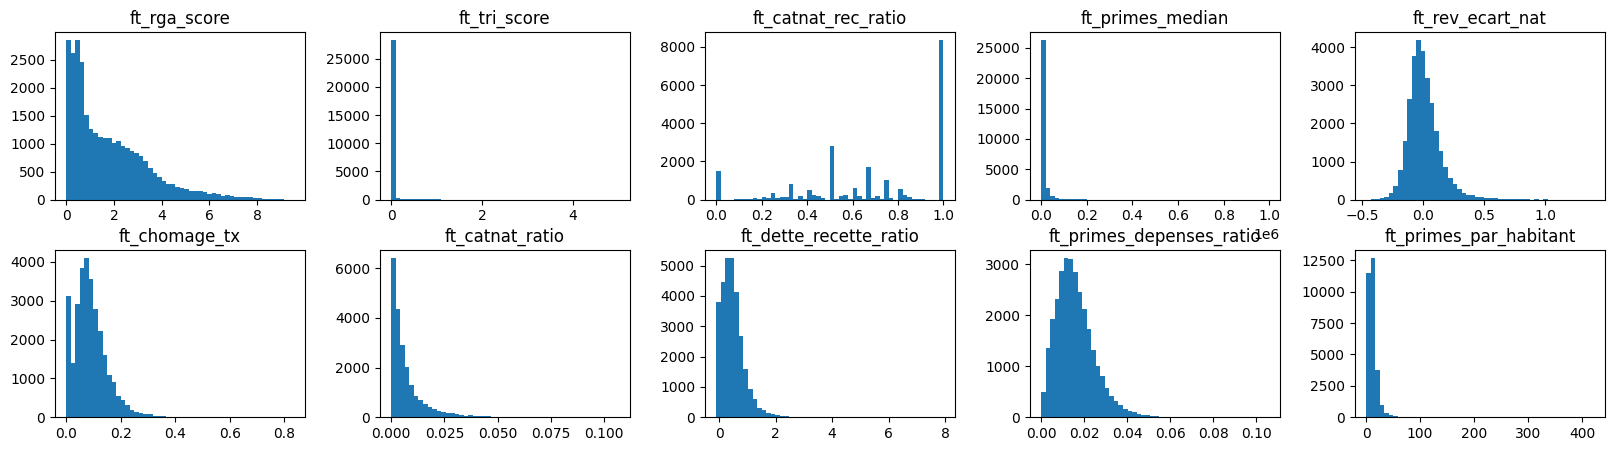

In [23]:
full[features_available].hist(bins=50, figsize=(20, 5), layout=(2, 5), grid=False, edgecolor='none')

In [24]:
full.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 29712 entries, 0 to 34954
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   codgeo                    29712 non-null  str     
 1   dep                       29712 non-null  str     
 2   reg                       29712 non-null  str     
 3   libgeo                    29712 non-null  str     
 4   geometry                  29712 non-null  geometry
 5   total_maisons             29550 non-null  float64 
 6   ft_rga_score              29550 non-null  float64 
 7   ft_tri_score              29550 non-null  float64 
 8   catnat_total              21416 non-null  float64 
 9   catnat_rec                21416 non-null  float64 
 10  catnat_unrec              21416 non-null  float64 
 11  ft_catnat_rec_ratio       21416 non-null  float64 
 12  ft_primes_median          29712 non-null  float64 
 13  depenses_fonct            29712 non-null  f

## Clusterings


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats.mstats import winsorize
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import QuantileTransformer

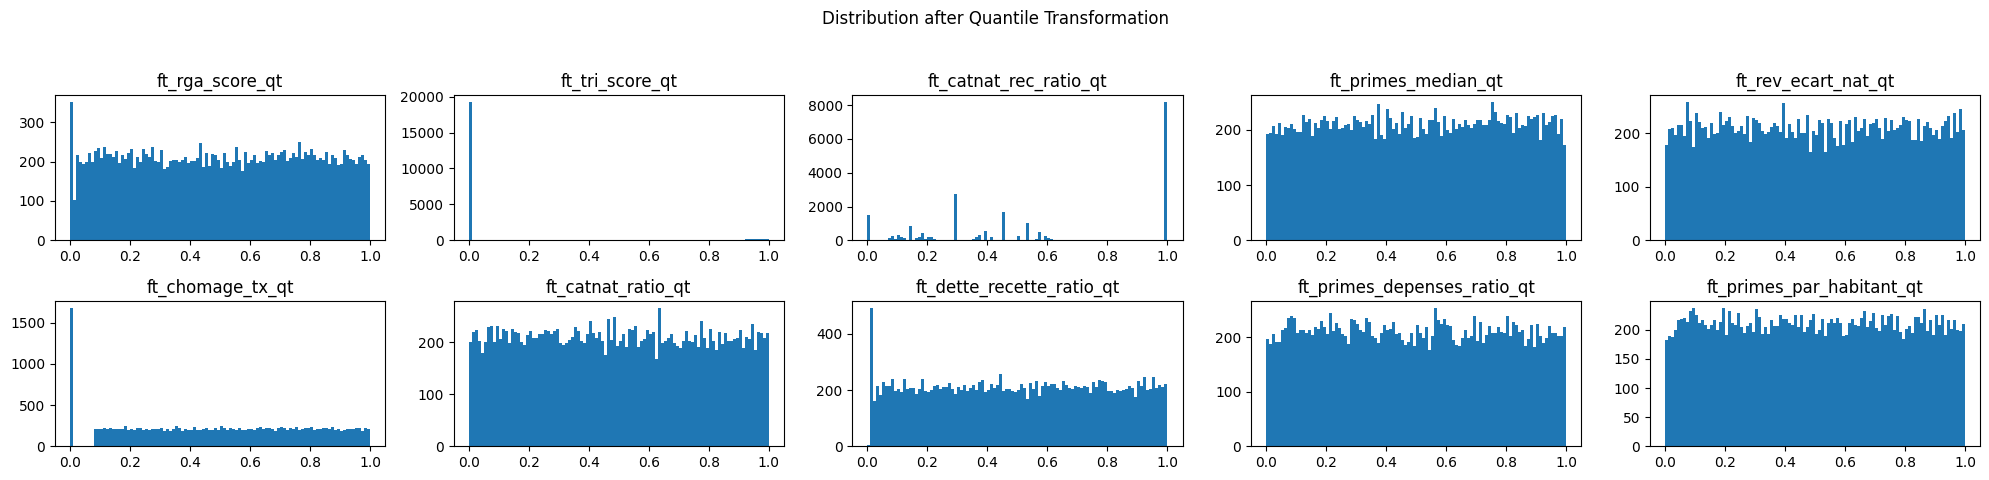

In [32]:
# Load the communes with features
df = pd.read_parquet('../csv_large/com_with_features.parquet', filters=[('catnat_total', '>=', CATNAT_MIN)])
df['geometry'] = gpd.GeoSeries.from_wkb(df['geometry'])



df['ft_catnat_rec_ratio'] = df['ft_catnat_rec_ratio'].fillna(1)
df['ft_catnat_ratio'] = df['ft_catnat_ratio'].fillna(0)
df = df.dropna(how='any')


# We keep and scale features
features_col = [col for col in full.columns if col.startswith("ft_")]
df = df [['codgeo', 'geometry'] + features_col]



# Apply Quantile Transformer to feature columns
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
X_quantile = qt.fit_transform(df[features_col])

# Convert back to DataFrame for easier handling/visualization
features_qt = [f + '_qt' for f in features_col]
df_qt = pd.DataFrame(X_quantile, columns=features_qt, index=df.index)
df = pd.concat([df, df_qt], axis=1)

# Check the new distribution
df_qt.hist(bins=100, figsize=(20, 5), layout=(2, 5), grid=False, edgecolor='none')
plt.suptitle('Distribution after Quantile Transformation')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])





In [33]:
df.head()

,codgeo,geometry,ft_rga_score,ft_tri_score,ft_catnat_rec_ratio,ft_primes_median,ft_rev_ecart_nat,ft_chomage_tx,ft_catnat_ratio,ft_dette_recette_ratio,...,ft_rga_score_qt,ft_tri_score_qt,ft_catnat_rec_ratio_qt,ft_primes_median_qt,ft_rev_ecart_nat_qt,ft_chomage_tx_qt,ft_catnat_ratio_qt,ft_dette_recette_ratio_qt,ft_primes_depenses_ratio_qt,ft_primes_par_habitant_qt
0,01001,"POLYGON ((846981.436 6564107.36, 847017.457 65...",0.604749,0.0,1.000000,6602.17,0.118718,0.021739,0.001179,0.899708,...,0.217360,0.0,1.000000,0.520568,0.848348,0.094447,0.171385,0.881256,0.358621,0.363326
2,01004,"POLYGON ((884889.404 6539629.931, 884795.75 65...",1.831899,0.0,0.625000,58121.66,-0.061525,0.120437,0.000525,0.368014,...,0.512894,0.0,0.413413,0.958695,0.312813,0.747917,0.069676,0.425522,0.065109,0.074121
5,01007,"POLYGON ((886027.651 6548170.9, 886971.388 654...",2.366935,0.0,0.875000,14696.63,0.077123,0.082157,0.002711,0.445624,...,0.621224,0.0,0.610110,0.787025,0.772773,0.495695,0.360776,0.517026,0.210291,0.140862
10,01012,"POLYGON ((892079.094 6549788.887, 892677.034 6...",0.721939,0.0,0.666667,5597.10,0.051560,0.036153,0.008824,0.473193,...,0.263500,0.0,0.458959,0.446567,0.709710,0.143856,0.747079,0.552718,0.635833,0.822164
11,01013,"POLYGON ((894931.917 6531575.79, 894377.202 65...",0.990991,0.0,1.000000,6425.69,-0.038995,0.000000,0.006944,1.595233,...,0.334192,0.0,1.000000,0.509907,0.399900,0.000000,0.666667,0.982540,0.906913,0.989559


In [ ]:
# Let's prepare the data

# 1. On enlève ou remplace les valeurs manquantes + écrettage


features = [
    'ft_rev_ecart_nat',
    'ft_chomage_tx',
    'ft_rga_score',
    'ft_tri_score',
    'ft_catnat_ratio',
    'ft_catnat_rec_ratio',
    'ft_dette_recette_ratio',
    'ft_primes_par_habitant',
    'ft_primes_median',
    'ft_primes_depenses_ratio'
    ]

features = [feat+'_qt' for feat in features] 
X = df[features].copy()
# X_scaled = X

# 3. Standardisation 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# X_scaled = scaler.fit_transform(X_imputed)

print(df_qt.shape)

# # Check distribution
# df_qt[features].hist(bins=100, figsize=(20, 5), layout=(2, 6), grid=False, edgecolor='none')
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])


(21065, 10)


In [35]:
#[Optional] Identify optimum cluster count
results = []
for k in range(3, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    results.append({'k': k, 'silhouette': score})

# 3. Affichage des scores
perf_df = pd.DataFrame(results)
perf_df.head(10)

,k,silhouette
0,3,0.136110
1,4,0.155103
2,5,0.147836
3,6,0.140381
4,7,0.140443
5,8,0.140621


In [36]:
# 4. Modélisation K-Means 
K_CLUSTERS = int(perf_df.iloc[perf_df.silhouette.idxmax()].k)
kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, df['cluster'])
print(f"Silhouette Score: {score}")

# 5. Extraction du sens : Profilage des clusters (Expliquer le 'Pourquoi')
profile = df.groupby('cluster')[features].mean().round(3)
profile['nb_communes'] = df.groupby('cluster').size()


# 6. Ajout des couleurs
cols_high_is_bad = [c for c in features if c in ('ft_rga_score_qt', 'ft_tri_score_qt', 'ft_chomage_tx_qt', 'ft_catnat_ratio_qt', 'ft_dette_recette_ratio_qt', 'ft_primes_par_habitant_qt', 'ft_primes_median_qt', 'ft_primes_depenses_ratio_qt')]
cols_high_is_good = [c for c in features if c not in cols_high_is_bad]

profile.style\
    .background_gradient(cmap='RdYlGn', subset=cols_high_is_good, axis=0)\
    .background_gradient(cmap='RdYlGn_r', subset=cols_high_is_bad, axis=0)\
    .background_gradient(cmap='Blues', subset=['nb_communes'], axis=0)\
    .format(precision=3)



Silhouette Score: 0.1551029244435063


,ft_rev_ecart_nat_qt,ft_chomage_tx_qt,ft_rga_score_qt,ft_tri_score_qt,ft_catnat_ratio_qt,ft_catnat_rec_ratio_qt,ft_dette_recette_ratio_qt,ft_primes_par_habitant_qt,ft_primes_median_qt,ft_primes_depenses_ratio_qt,nb_communes
cluster,,,,,,,,,,,
0,0.300,0.615,0.328,0.002,0.607,0.710,0.471,0.759,0.446,0.720,6200
1,0.583,0.510,0.489,0.000,0.257,0.608,0.567,0.279,0.658,0.260,6904
2,0.573,0.596,0.567,0.958,0.266,0.515,0.531,0.293,0.775,0.240,1822
3,0.589,0.339,0.662,0.001,0.726,0.415,0.446,0.546,0.309,0.617,6139


### Clustering with AgglomerativeClustering


In [116]:
# 1. On garde nos features clés (en écrêtant la ligne budgétaire extrême)

features = [
    'ft_rev_ecart_nat',
    # 'ft_chomage_tx',
    'ft_rga_score',
    # 'ft_tri_score',
    'ft_catnat_ratio',
    'ft_catnat_rec_ratio',
    'ft_dette_recette_ratio',
    # 'ft_primes_par_habitant',
    # 'ft_primes_median',
    'ft_primes_depenses_ratio'
    ]

# for feat in features:
#     df[f'{feat}_qt'] = winsorize(df[feat], limits=[QUANT_ECRET, QUANT_ECRET])

features = [feat+'_qt' for feat in features] 
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Le Modèle Agglomératif

model_hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['cluster_hc'] = model_hc.fit_predict(X_scaled)

# 3. Profilage pour trouver le cluster "Double Peine"
profil_hc = df.groupby('cluster_hc')[features].mean().round(2)
profil_hc['nb_communes'] = df.groupby('cluster_hc').size()

# 4. Score de Silhouette
score = silhouette_score(X_scaled, df['cluster_hc'])
print(f"Silhouette Score: {score}")

Silhouette Score: 0.10076428162232788


In [117]:
# 6. Ajout des couleurs
cols_high_is_bad = [c for c in features if c in ('ft_rga_score_qt', 'ft_tri_score_qt', 'ft_chomage_tx_qt', 'ft_catnat_ratio_qt', 'ft_dette_recette_ratio_qt', 'ft_primes_par_habitant_qt', 'ft_primes_median_qt', 'ft_primes_depenses_ratio_qt')]
cols_high_is_good = [c for c in features if c not in cols_high_is_bad]

profil_hc.style\
    .background_gradient(cmap='RdYlGn', subset=cols_high_is_good, axis=0)\
    .background_gradient(cmap='RdYlGn_r', subset=cols_high_is_bad, axis=0)\
    .background_gradient(cmap='Blues', subset=['nb_communes'], axis=0)\
    .format(precision=3)

,ft_rev_ecart_nat_qt,ft_rga_score_qt,ft_catnat_ratio_qt,ft_catnat_rec_ratio_qt,ft_dette_recette_ratio_qt,ft_primes_depenses_ratio_qt,nb_communes
cluster_hc,,,,,,,
0,0.130,3.250,0.000,0.740,0.390,0.010,5563
1,-0.030,2.350,0.000,0.400,0.460,0.010,4736
2,-0.060,0.900,0.000,0.980,0.380,0.020,4663
3,-0.050,1.980,0.020,0.560,0.390,0.020,3831
4,-0.010,1.490,0.000,0.740,1.140,0.010,2272


### Display on map


<Axes: >

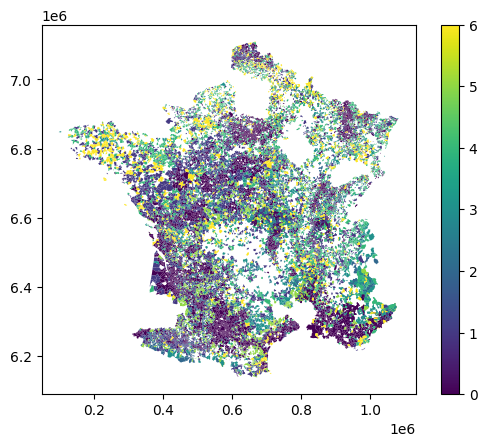

In [175]:
# Display Clustered communes on map
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:2153')
gdf.plot(column='cluster_hc', legend=True)

# Scoring


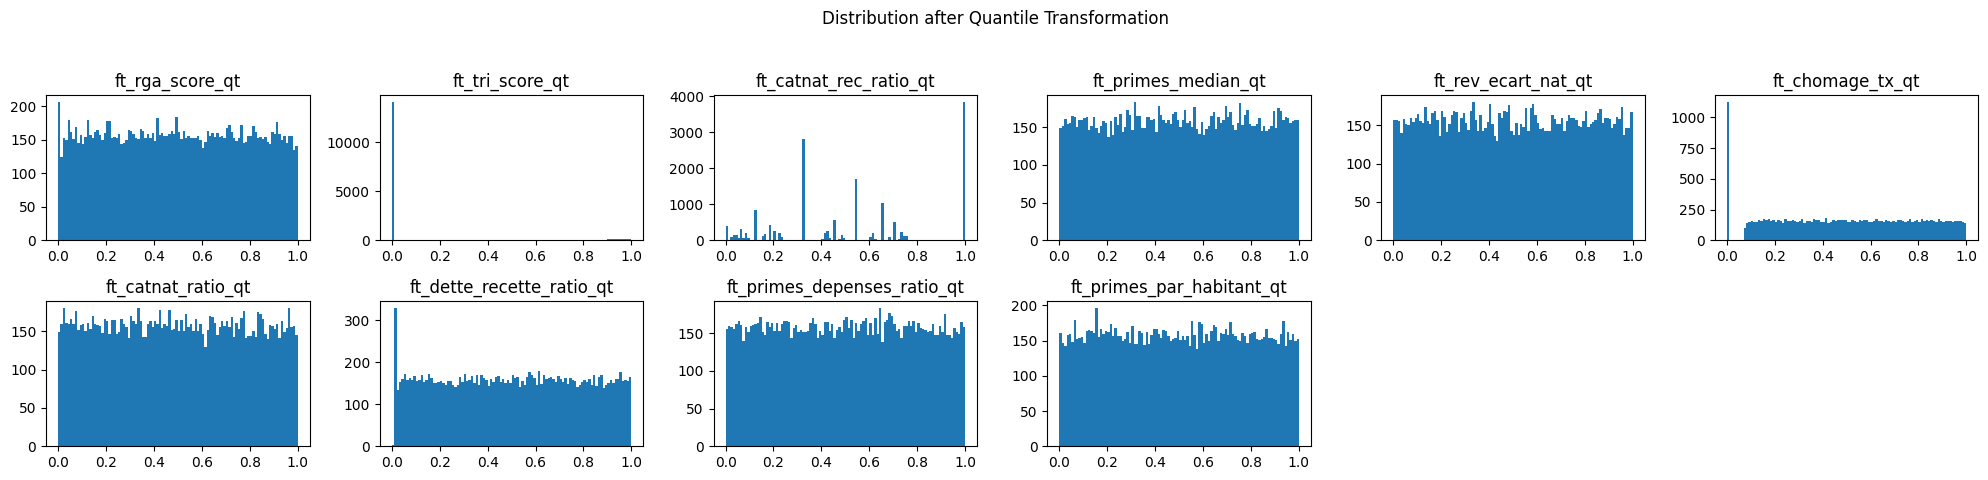

In [14]:
from sklearn.preprocessing import QuantileTransformer

# Load the communes with features
# cols_to_load = ['codgeo'] , 'rga_score_scaled', 'tri_score_scaled', 'catnat_rec_ratio', 'rev_med', 'rev_ecart_nat', 'primes_ratio', 'catnat_ratio', 'geometry', 'chomage_tx']
df = pd.read_parquet('../csv_large/com_with_features.parquet', filters=[('catnat_total', '>', CATNAT_MIN)])
df['geometry'] = gpd.GeoSeries.from_wkb(df['geometry'])
df = gpd.GeoDataFrame(df, crs='EPSG:2154')#.to_crs('EPSG:4326')

features_col = [col for col in df.columns if col.startswith('ft_')]

# Apply Quantile Transformer to feature columns
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
X_quantile = qt.fit_transform(df[features_col])

# Convert back to DataFrame for easier handling/visualization
features_qt = [f + '_qt' for f in features_col]
df_qt = pd.DataFrame(X_quantile, columns=features_qt, index=df.index)

# We add back the quantile transformed data
df = pd.concat([df, df_qt], axis=1)

# Check the new distribution
df_qt.hist(bins=100, figsize=(20, 5), layout=(2, 6), grid=False, edgecolor='none')
plt.suptitle('Distribution after Quantile Transformation')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

In [10]:
df.head()

,codgeo,dep,reg,libgeo,geometry,total_maisons,ft_rga_score,ft_tri_score,catnat_total,catnat_rec,...,ft_rga_score_qt,ft_tri_score_qt,ft_catnat_rec_ratio_qt,ft_primes_median_qt,ft_rev_ecart_nat_qt,ft_chomage_tx_qt,ft_catnat_ratio_qt,ft_dette_recette_ratio_qt,ft_primes_depenses_ratio_qt,ft_primes_par_habitant_qt
2,01004,01,84,Ambérieu-en-Bugey,"POLYGON ((884889.40373 6539629.93086, 884795.7...",3254.0,1.831899,0.0,8.0,5.0,...,0.430391,0.0,0.483984,0.948992,0.322322,0.735552,0.052376,0.417178,0.074027,0.081739
5,01007,01,84,Ambronay,"POLYGON ((886027.65133 6548170.89982, 886971.3...",1116.0,2.366935,0.0,8.0,7.0,...,0.539689,0.0,0.752252,0.751927,0.773556,0.471557,0.285876,0.508123,0.237135,0.155129
10,01012,01,84,Aranc,"POLYGON ((892079.0943 6549788.88724, 892677.03...",196.0,0.721939,0.0,3.0,2.0,...,0.202748,0.0,0.548549,0.406502,0.712713,0.134808,0.657658,0.543470,0.664054,0.823725
14,01016,01,84,Arbigny,"POLYGON ((854027.04461 6597784.4077, 853918.98...",216.0,1.833333,0.0,2.0,2.0,...,0.430721,0.0,1.000000,0.313329,0.554555,0.181189,0.413980,0.729598,0.609869,0.511586
18,01022,01,84,Artemare,"POLYGON ((909649.89119 6534153.11505, 909455.3...",484.0,0.506198,0.0,2.0,2.0,...,0.132923,0.0,1.000000,0.648609,0.379379,0.360656,0.183162,0.796861,0.337775,0.447197


In [11]:
com_vuln.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [20]:
com_vuln = df[
    (df.ft_rga_score_qt > 0.5)
    & (df.ft_catnat_rec_ratio_qt < 0.5)
    & (df.ft_rev_ecart_nat_qt < 0.2)
    & (df.ft_dette_recette_ratio_qt > 0.8)
    & (df.ft_primes_depenses_ratio_qt > 0.8)
]
com_vuln.explore()

In [22]:
com_vuln.count()

codgeo                         35
dep                            35
reg                            35
libgeo                         35
geometry                       35
total_maisons                  35
ft_rga_score                   35
ft_tri_score                   35
catnat_total                   35
catnat_rec                     35
catnat_unrec                   35
ft_catnat_rec_ratio            35
ft_primes_median               35
depenses_fonct                 35
pop                            35
recettes                       35
dettes                         35
rev_med                        35
ft_rev_ecart_nat               35
ft_chomage_tx                  35
ft_catnat_ratio                35
ft_dette_recette_ratio         35
ft_primes_depenses_ratio       35
ft_primes_par_habitant         35
ft_rga_score_qt                35
ft_tri_score_qt                35
ft_catnat_rec_ratio_qt         35
ft_primes_median_qt            35
ft_rev_ecart_nat_qt            35
ft_chomage_tx_

# Check data


In [9]:
q = """
SELECT *
FROM pcc.main.budget_per_compte_communes
--LIMIT 1000
"""

PCC_DUCKDB_FILE = "dev.duckdb"

con = duckdb.connect(database=PCC_DUCKDB_FILE, read_only=True)
con.sql(f"ATTACH '{PCC_DUCKDB_FILE}' AS pcc;")
res = con.sql(q)
df = res.df()
con.close()


# test = run_duckdb_query(q)
test.head()

NameError: name 'test' is not defined

In [11]:
df.type_compte.unique()

<ArrowStringArray>
[           'dettes', 'prime d'assurance',          'produits',
          'depenses',   'immo corporelle', 'immo incorporelle',
     'immo en cours',   'immo financière',    'amortissements',
     'dépréciations',       'autres immo']
Length: 11, dtype: str

In [4]:
len(test.code_geo_from_siren.unique())

34935

In [5]:
test.type_compte.unique()

<ArrowStringArray>
[           'dettes',          'produits',          'depenses',
   'immo corporelle', 'immo incorporelle',     'immo en cours',
   'immo financière',    'amortissements',     'dépréciations',
       'autres immo', 'prime d'assurance']
Length: 11, dtype: str